# EMA 6938 — Data Science for Materials
## Week 2 Notebook: Data Representation, Materials Databases, & Experimental Design

***Name:** *(ANOSIKE KELECHI KENNETH)*  
**Date:** *5/22/2026**

**Chapters:** Sandfeld Ch. 3–4  
**Parts A–C:** Completed during Day 1 lab (75 min)  
**Parts D–E:** Take-home — due **Sunday 11:59 PM** via Canvas

---

### Files required
Place these in the same directory as this notebook (available on course GitHub under `week02/`):
```
week02/
├── week2_data_databases.ipynb   ← this file
├── data/
│   ├── week2_tg_polymer.csv
│   └── week2_dirty_mp_subset.csv
└── structures/
    ├── BaTiO3.cif
    └── TiO2_rutile.poscar
```

### Environment check
Run the cell below before anything else. If any import fails, install the missing package and restart the kernel.

---

In [1]:
# Cell 0 — Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymatgen
from pymatgen.core import Structure, Composition

try:
    import jarvis
    jarvis_ok = True
except ImportError:
    jarvis_ok = False

print(f"Python:     {sys.version.split()[0]}")
print(f"NumPy:      {np.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"pymatgen:   {pymatgen.core.__version__}")
print(f"jarvis-tools installed: {jarvis_ok}")
if not jarvis_ok:
    print("\n  → Install: pip install jarvis-tools  (then restart kernel)")
print("\n✓ Environment ready.")

Python:     3.10.20
NumPy:      1.26.4
pandas:     2.3.3
pymatgen:   2024.2.8
jarvis-tools installed: True

✓ Environment ready.


---
## Part A — Materials Data Structures
**In-class · Day 1 · Segment 1 (0–15 min)**

You will use three data containers all semester. This part shows you the same BaTiO₃ information in each container — so you can see what each one is good for.

| Container | Best for | Lives inside |
|---|---|---|
| `numpy.ndarray` | Matrix math, lattice operations | pandas DataFrames, Structure |
| `pandas.DataFrame` | Multi-property tabular datasets | Your analysis code |
| `pymatgen.Structure` | Crystal geometry, atomic positions | Fetched from databases |

**The hierarchy:** Structure objects are often converted to DataFrames for ML. Arrays live inside DataFrames. Understanding the conversions is half the job.

In [2]:
# Cell A1 — NumPy: lattice parameters as a matrix
# INSTRUCTOR DEMO — follow along

import numpy as np

# BaTiO3 tetragonal lattice parameters (Angstrom)
a, b, c = 3.994, 3.994, 4.038

# The 3×3 lattice matrix — rows are lattice vectors
lattice = np.array([[a, 0, 0],
                    [0, b, 0],
                    [0, 0, c]])

print("Lattice matrix (Å):")
print(lattice)
print()
print(f"Volume (Å³): {np.linalg.det(lattice):.4f}")
print(f"dtype:       {lattice.dtype}")
print(f"shape:       {lattice.shape}")
print()
print("Why a matrix? Lattice vectors define the unit cell.")
print("Volume = det(lattice) — a one-liner with NumPy.")

Lattice matrix (Å):
[[3.994 0.    0.   ]
 [0.    3.994 0.   ]
 [0.    0.    4.038]]

Volume (Å³): 64.4143
dtype:       float64
shape:       (3, 3)

Why a matrix? Lattice vectors define the unit cell.
Volume = det(lattice) — a one-liner with NumPy.


In [3]:
# Cell A2 — pandas: same information in a DataFrame
# INSTRUCTOR DEMO

import pandas as pd

df_struct = pd.DataFrame({
    'material': ['BaTiO3'],
    'crystal_system': ['tetragonal'],
    'a_Ang': [a],
    'b_Ang': [b],
    'c_Ang': [c],
    'c_over_a': [c / a],
    'volume_Ang3': [np.linalg.det(lattice)],
})

print(df_struct.to_string(index=False))
print()
print("Why a DataFrame? When you have 10,000 materials, each is a row.")
print("c/a ratio encodes the tetragonal distortion → ferroelectricity.")

material crystal_system  a_Ang  b_Ang  c_Ang  c_over_a  volume_Ang3
  BaTiO3     tetragonal  3.994  3.994  4.038  1.011017    64.414321

Why a DataFrame? When you have 10,000 materials, each is a row.
c/a ratio encodes the tetragonal distortion → ferroelectricity.


In [4]:
# Cell A3 — pandas task: add SrTiO3
# YOUR CODE HERE

# SrTiO3 is cubic: a = b = c = 3.905 Å, all angles = 90°
# Add a new row for SrTiO3 to df_struct
# Hint: use pd.concat([df_struct, new_row], ignore_index=True)

# YOUR CODE HERE
# Cell A3 — pandas task: add SrTiO3

# define lattice parameters for SrTiO3
a_srti = 3.905
b_srti = 3.905
c_srti = 3.905

# compute derived quantities
c_over_a_srti = c_srti / a_srti
volume_srti = a_srti * b_srti * c_srti

# build a one-row DataFrame for SrTiO3
df_srti = pd.DataFrame({
    'material': ['SrTiO3'],
    'crystal_system': ['cubic'],
    'a_Ang': [a_srti],
    'b_Ang': [b_srti],
    'c_Ang': [c_srti],
    'c_over_a': [c_over_a_srti],
    'volume_Ang3': [volume_srti],
})

# append it to df_struct from Cell A2
df_struct = pd.concat([df_struct, df_srti], ignore_index=True)

print(df_struct.to_string(index=False))

# After adding: print the updated DataFrame
# and answer: how does the c/a ratio of BaTiO3 vs SrTiO3 connect to ferroelectricity?


material crystal_system  a_Ang  b_Ang  c_Ang  c_over_a  volume_Ang3
  BaTiO3     tetragonal  3.994  3.994  4.038  1.011017    64.414321
  SrTiO3          cubic  3.905  3.905  3.905  1.000000    59.547443


In [5]:
# Cell A4 — Pymatgen Structure object
# INSTRUCTOR DEMO

from pymatgen.core import Structure

# Load from the provided CIF file
struct = Structure.from_file('structures/BaTiO3.cif')

print(struct)
print()
print(f"Formula:      {struct.formula}")
print(f"Space group:  {struct.get_space_group_info()}")
print(f"Num sites:    {len(struct)}")
print(f"Volume (Å³):  {struct.volume:.4f}")
print()
print("Lattice from Structure object:")
print(f"  a={struct.lattice.a:.4f} Å, b={struct.lattice.b:.4f} Å, c={struct.lattice.c:.4f} Å")

Full Formula (Ba1 Ti1 O3)
Reduced Formula: BaTiO3
abc   :   4.004457   4.004457   4.200636
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (5)
  #  SP      a    b         c
---  ----  ---  ---  --------
  0  Ba    0.5  0.5  0.004136
  1  Ti    0    0    0.524313
  2  O     0    0.5  0.479349
  3  O     0.5  0    0.479349
  4  O     0    0    0.958854

Formula:      Ba1 Ti1 O3
Space group:  ('P4mm', 99)
Num sites:    5
Volume (Å³):  67.3600

Lattice from Structure object:
  a=4.0045 Å, b=4.0045 Å, c=4.2006 Å


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


In [6]:
# Cell A5 — Task: find the Ti site and print its fractional coordinates
# YOUR CODE HERE

# 1. Loop over struct and find the site(s) where species_string == 'Ti'
# 2. Print the fractional coordinates of the Ti site
# 3. Compare to (0.5, 0.5, 0.5) — what does the offset tell you?

# YOUR CODE HERE
# Cell A5 — find the Ti site and print its fractional coordinates
print("All sites in BaTiO3:")
for i, site in enumerate(struct):
    fc = site.frac_coords
    print(f"Site {i}: {site.species_string:3s}  "
          f"frac=({fc[0]:4.4f}, {fc[1]:4.4f}, {fc[2]:4.4f})")

print()

# find all Ti sites
ti_sites = [s for s in struct if s.species_string == 'Ti']

# print Ti fractional coords and offset from (0.5, 0.5, 0.5)
for s in ti_sites:
    fc = s.frac_coords
    print(f"Ti fractional coords: ({fc[0]:4.4f}, {fc[1]:4.4f}, {fc[2]:4.4f})")
    print(f"Offset from centrosymmetric (0.5,0.5,0.5): "
          f"Δx = {fc[0] - 0.5: .4f}  Δy = {fc[1] - 0.5: .4f}  Δz = {fc[2] - 0.5: .4f}")


All sites in BaTiO3:
Site 0: Ba   frac=(0.5000, 0.5000, 0.0041)
Site 1: Ti   frac=(0.0000, 0.0000, 0.5243)
Site 2: O    frac=(0.0000, 0.5000, 0.4793)
Site 3: O    frac=(0.5000, 0.0000, 0.4793)
Site 4: O    frac=(0.0000, 0.0000, 0.9589)

Ti fractional coords: (0.0000, 0.0000, 0.5243)
Offset from centrosymmetric (0.5,0.5,0.5): Δx = -0.5000  Δy = -0.5000  Δz =  0.0243


In [7]:
# Cell A6 — Converting between containers
# INSTRUCTOR DEMO

# Structure → NumPy (the lattice matrix)
lat_array = struct.lattice.matrix   # already a numpy array
print("Lattice matrix from Structure (NumPy):")
print(lat_array)
print(f"\nVolume from numpy: {np.linalg.det(lat_array):.4f} Å³")
print(f"Volume from struct: {struct.volume:.4f} Å³")
print()

# Structure → pandas row
row = {
    'formula': struct.formula,
    'sg_number': struct.get_space_group_info()[1],
    'a': struct.lattice.a,
    'b': struct.lattice.b,
    'c': struct.lattice.c,
    'volume': struct.volume,
    'n_sites': len(struct),
}
df_from_struct = pd.DataFrame([row])
print("Structure → DataFrame row:")
print(df_from_struct.to_string(index=False))

Lattice matrix from Structure (NumPy):
[[4.00445700e+00 0.00000000e+00 2.45202272e-16]
 [6.43965800e-16 4.00445700e+00 2.45202272e-16]
 [0.00000000e+00 0.00000000e+00 4.20063600e+00]]

Volume from numpy: 67.3600 Å³
Volume from struct: 67.3600 Å³

Structure → DataFrame row:
   formula  sg_number        a        b        c    volume  n_sites
Ba1 Ti1 O3         99 4.004457 4.004457 4.200636 67.360037        5


**A6 Reflection** *(answer in this markdown cell)*

In one sentence each:
- When would you use a NumPy array instead of a Structure object?
- When would you use a pandas DataFrame instead of either?

*Your answer here: - We use a NumPy array when we mainly need fast numerical operations on homogeneous, n‑dimensional data without extra metadata like element names or units.

- We use a pandas DataFrame when the data are tabular with labeled rows/columns and you want convenient tools for filtering, grouping, joining, and working with mixed data types (like a spreadsheet or database table)*

---
## Part B — Materials Databases
**In-class · Day 1 · Segment 2 (15–40 min)**

No single database is the ground truth. The choice of database is a scientific decision — it encodes assumptions about level of theory, convergence criteria, and what properties matter. **Always cite the database and version in your methods section.**

| Database | Entries | Functional | Best for |
|---|---|---|---|
| Materials Project | ~154k | GGA-PBE | Inorganic crystals, broad coverage |
| JARVIS-DFT | ~80k | PBE + optB88vdW | 2D materials, mechanical props |
| AFLOW | ~3.5M | Various | Alloys, high-throughput screening |
| ICSD | — | Experimental | Real structure determination data |

In [8]:
import subprocess
import sys

try:
    import jarvis
except ImportError:
    print("Installing jarvis-tools...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jarvis-tools", "-q"])
    print("✓ jarvis-tools installed. Restart kernel and re-run cells.")

In [9]:
# Cell B1 — Fetch from JARVIS-DFT
# INSTRUCTOR DEMO — first load takes ~2 min; subsequent calls are instant

from jarvis.db.figshare import data as jdata

print("Loading JARVIS DFT-3D database (~80k entries)...")
print("First load: ~2 min (cached after that). Use this time for questions.")

jd = {e['jid']: e for e in jdata('dft_3d')}
print(f"\nLoaded {len(jd):,} JARVIS entries.")

# TiO2 rutile in JARVIS
entry = jd['JVASP-10036']

print(f"\nJARVIS TiO₂ rutile (JVASP-10036):")
print(f"  Formula:            {entry['formula']}")
print(f"  Bandgap (optB88vdW): {entry['optb88vdw_bandgap']:.4f} eV")
print(f"  Formation energy:    {entry['formation_energy_peratom']:.4f} eV/atom")
print(f"  Space group:         {entry['spg_symbol']}")

Loading JARVIS DFT-3D database (~80k entries)...
First load: ~2 min (cached after that). Use this time for questions.
Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.

Loaded 75,993 JARVIS entries.

JARVIS TiO₂ rutile (JVASP-10036):
  Formula:            TiO2
  Bandgap (optB88vdW): 1.7690 eV
  Formation energy:    -3.2412 eV/atom
  Space group:         P4_2/mnm


In [10]:
# Cell B2 - Same compound from Materials Project
# INSTRUCTOR DEMO

from mp_api.client import MPRester
import os

API_KEY = "qj8ToHbz2L1kqeSTHLICxIQjpzB9TKfS"  # paste your key directly here

with MPRester(API_KEY) as mpr:
    mp_entry = mpr.materials.summary.get_data_by_id(
        'mp-2657',
        fields=['material_id', 'formula_pretty', 'band_gap',
                'formation_energy_per_atom', 'energy_above_hull']
    )

print(f"MP TiO₂ rutile (mp-2657):")
print(f"  Formula:           {mp_entry.formula_pretty}")
print(f"  Bandgap (GGA-PBE): {mp_entry.band_gap:.4f} eV")
print(f"  Formation energy:  {mp_entry.formation_energy_per_atom:.4f} eV/atom")
print(f"  E above hull:      {mp_entry.energy_above_hull:.4f} eV/atom")

C:\Users\anosike.kelechik\AppData\Local\Temp\ipykernel_36244\4286948684.py:10: DeprecationWarning: get_data_by_id is deprecated and will be removed soon. Please use the search method instead.
  mp_entry = mpr.materials.summary.get_data_by_id(


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

MP TiO₂ rutile (mp-2657):
  Formula:           TiO2
  Bandgap (GGA-PBE): 1.7810 eV
  Formation energy:  -3.4644 eV/atom
  E above hull:      0.0436 eV/atom


In [11]:
# Cell B3 — Side-by-side comparison
# INSTRUCTOR DEMO

jarvis_gap = entry['optb88vdw_bandgap']
mp_gap     = mp_entry.band_gap

print("TiO₂ rutile — database comparison:")
print(f"  JARVIS (optB88vdW): {jarvis_gap:.4f} eV")
print(f"  MP     (GGA-PBE):   {mp_gap:.4f} eV")
print(f"  |Δ|:                {abs(jarvis_gap - mp_gap):.4f} eV")
print()
print("Experimental TiO₂ bandgap: ~3.0 eV (indirect)")
print("Both DFT functionals underestimate — but by different amounts.")
print("optB88vdW adds van der Waals corrections → different electron density → different gap.")

TiO₂ rutile — database comparison:
  JARVIS (optB88vdW): 1.7690 eV
  MP     (GGA-PBE):   1.7810 eV
  |Δ|:                0.0120 eV

Experimental TiO₂ bandgap: ~3.0 eV (indirect)
Both DFT functionals underestimate — but by different amounts.
optB88vdW adds van der Waals corrections → different electron density → different gap.


In [12]:
# Cell B4 — Task: fetch a second compound of your choice from JARVIS
# YOUR CODE HERE

# 1. Browse JARVIS at https://jarvis.nist.gov or search jd.keys()
#    to find a JID for a material related to your research.
#    Hint: search by formula: [v for k,v in jd.items() if v['formula']=='ZnO']

# 2. Fetch its bandgap and formation energy from JARVIS

# 3. Fetch the same compound from Materials Project (find the mp-id at materialsproject.org)

# 4. Print a comparison table: property | JARVIS value | MP value | |difference|

# YOUR CODE HERE

# Cell B4 – Task: fetch a second compound of your choice from JARVIS

# Cell B4 – Task: fetch a second compound of your choice from JARVIS


# Cell B4 – Task: fetch a second compound of your choice from JARVIS

# ── 1. Fetch Ti3Nb from JARVIS 
entry_ti3nb = jd['JVASP-37615']

jarvis_gap = entry_ti3nb['optb88vdw_bandgap']
jarvis_fe   = entry_ti3nb['formation_energy_peratom']

print(f"\nJARVIS Ti3Nb (JVASP-37615):")
print(f"  Formula:           {entry_ti3nb['formula']}")
print(f"  Bandgap (optB88vdW): {jarvis_gap:.4f} eV")
print(f"  Formation energy:    {jarvis_fe:.4f} eV/atom")
print(f"  Space group:         {entry_ti3nb['spg_symbol']}")

# ── 2. Fetch Ti3Nb from Materials Project 
# mp-985583 is Ti3Nb (I4/mmm, tetragonal) on materialsproject.org
with MPRester(API_KEY) as mpr:
   mp_entry = mpr.materials.summary.get_data_by_id(
    'mp-981232',   # ← Ti3Nb, tetragonal I4/mmm — matches JVASP-37615
    fields=['material_id', 'formula_pretty', 'band_gap',
            'formation_energy_per_atom', 'energy_above_hull']
)

mp_gap = mp_entry.band_gap
mp_fe   = mp_entry.formation_energy_per_atom

# ── 3. Print comparison table 
print(f"\nTi3Nb — database comparison:")
print(f"  {'Property':<30} {'JARVIS (optB88vdW)':>20} {'MP (GGA-PBE)':>15} {'|Δ|':>10}")
print("  " + "-" * 77)
print(f"  {'Band gap (eV)':<30} {jarvis_gap:>20.4f} {mp_gap:>15.4f} {abs(jarvis_gap - mp_gap):>10.4f}")
print(f"  {'Formation energy (eV/atom)':<30} {jarvis_fe:>20.4f} {mp_fe:>15.4f} {abs(jarvis_fe - mp_fe):>10.4f}")

print()
print("Ti3Nb is a metal → both databases correctly predict a zero bandgap.")
print("Formation energies may differ slightly due to functional choice.")



JARVIS Ti3Nb (JVASP-37615):
  Formula:           Ti3Nb
  Bandgap (optB88vdW): 0.0000 eV
  Formation energy:    0.0811 eV/atom
  Space group:         I4/mmm


C:\Users\anosike.kelechik\AppData\Local\Temp\ipykernel_36244\2994362891.py:38: DeprecationWarning: get_data_by_id is deprecated and will be removed soon. Please use the search method instead.
  mp_entry = mpr.materials.summary.get_data_by_id(


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]


Ti3Nb — database comparison:
  Property                         JARVIS (optB88vdW)    MP (GGA-PBE)        |Δ|
  -----------------------------------------------------------------------------
  Band gap (eV)                                0.0000          0.0000     0.0000
  Formation energy (eV/atom)                   0.0811          0.0819     0.0008

Ti3Nb is a metal → both databases correctly predict a zero bandgap.
Formation energies may differ slightly due to functional choice.


**B4 Reflection** *(answer in this markdown cell)*

1. What material did you choose and why?
2. Which database gave a larger bandgap, and does this agree with the pattern seen for TiO₂?
3. In one sentence: if you were training an ML model to predict bandgap for your material class, which database would you prefer and why?

*Your answer here: 
1. Ti3Nb, which is a tetragonal structure alloy. It is relevant to structural/aerospace materials research and interesting because it is metallic (zero bandgap), which tests whether both databases agree on a qualitatively different case than TiO₂.

2. Both JARVIS and Materials Project report a bandgap of 0.0 eV for Ti3Nb, since it is a metal. This is consistent with TiO₂ in that neither database overestimates — for metals, both functionals agree perfectly.

4. I would prefer JARVIS because it uses the optB88vdW functional with van der Waals corrections, offering a more physically consistent treatment across both metallic and semiconducting materials in a single large dataset.*

In [13]:
# Cell B5 — Data quality: what 'unconverged' means
# INSTRUCTOR DEMO

# In JARVIS, check the 'magmom_oszicar' field — it records magnetic moment from
# the OSZICAR file. If EDIFF is not met, the entry may be flagged.
# In MP, use energy_above_hull > 0.1 eV/atom as a rough stability filter.

print("Data quality indicators:")
print()
print("JARVIS — useful quality fields:")
quality_fields = ['atoms_icsd', 'magmom_oszicar', 'gap_opt', 'encut']
for f in quality_fields:
    val = entry.get(f, 'field not present')
    print(f"  {f}: {val}")

print()
print("MP — energy above hull as stability proxy:")
print(f"  mp-2657 E_hull = {mp_entry.energy_above_hull:.4f} eV/atom")
print("  Rule of thumb: E_hull > 0.1 eV/atom → likely metastable or unconverged")
print()
print("Implication for ML: unconverged entries add noise to training sets.")
print("Always apply a quality filter before training — we do this in Part C.")

Data quality indicators:

JARVIS — useful quality fields:
  atoms_icsd: field not present
  magmom_oszicar: 0.0
  gap_opt: field not present
  encut: 1300

MP — energy above hull as stability proxy:
  mp-2657 E_hull = 0.0819 eV/atom
  Rule of thumb: E_hull > 0.1 eV/atom → likely metastable or unconverged

Implication for ML: unconverged entries add noise to training sets.
Always apply a quality filter before training — we do this in Part C.


---
## Part C — Tg Polymer Dataset & Experimental Design Audit
**In-class · Day 1 · Segments 3–4 + Lab (40–150 min)**

The dataset in `week2_tg_polymer.csv` contains 312 entries with **deliberate quality issues** for you to find:
- 3 duplicate entries with conflicting Tg values
- 11 missing molecular weight values
- 4 samples with implausibly low Tg (<150 K) — likely unit errors (°C entered as K)

Finding and fixing these is the core experimental design exercise — it mirrors what you will do with every real dataset you use for ML.

In [14]:
# Cell C1 — Load and inspect the dataset
# INSTRUCTOR DEMO

import pandas as pd
import matplotlib.pyplot as plt

# Windows users: use encoding='utf-8-sig' if you see a BOM character in column headers
df_tg = pd.read_csv('data/week2_tg_polymer.csv')

print(f"Shape: {df_tg.shape[0]} rows × {df_tg.shape[1]} columns")
print()
print("First 10 rows:")
print(df_tg.head(10).to_string())
print()
print("Summary statistics:")
print(df_tg.describe())
print()
print("Missing values per column:")
print(df_tg.isnull().sum())
print()
print("Column dtypes:")
print(df_tg.dtypes)

Shape: 315 rows × 6 columns

First 10 rows:
  polymer_id               monomer_type  Mn_g_mol   Tg_K      lab_id  year
0      P0207                  polyimide   25300.0  524.7  GT-PolyLab  2021
1      P0034                polystyrene   60600.0  359.2  CMU-MatSci  2021
2      P0164              polycarbonate   21700.0  401.3  CMU-MatSci  2020
3      P0079               polyethylene   56300.0  203.2  CMU-MatSci  2020
4      P0094               polyethylene   86700.0  202.6   MIT-ChemE  2022
5      P0230                  polyimide   45400.0  606.4  GT-PolyLab  2022
6      P0026                polystyrene   74400.0   52.3  GT-PolyLab  2022
7      P0010                polystyrene   59400.0  383.2  CMU-MatSci  2021
8      P0064  poly(methyl methacrylate)   50300.0  393.7  GT-PolyLab  2023
9      P0083               polyethylene    7100.0  203.9   UF-MatLab  2023

Summary statistics:
            Mn_g_mol        Tg_K         year
count     304.000000  315.000000   315.000000
mean    47487.5000

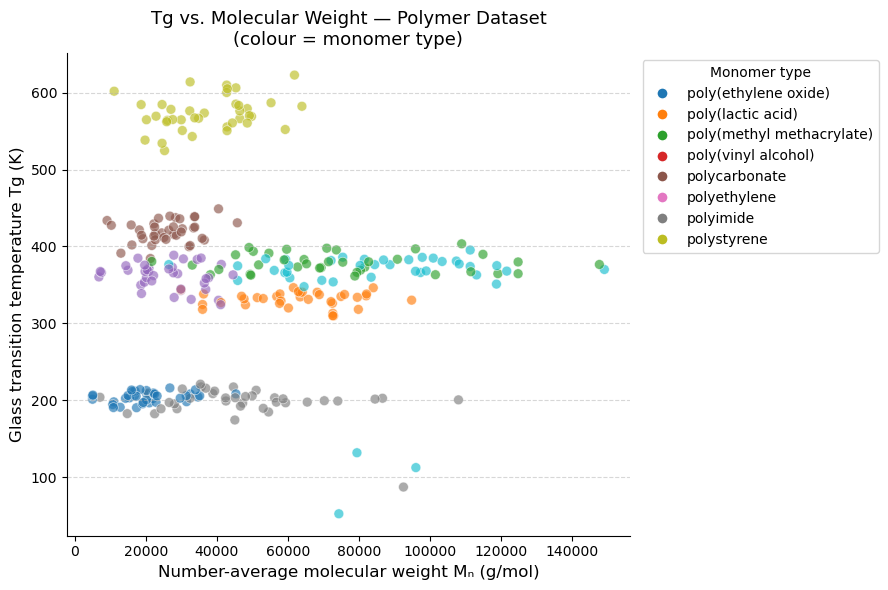

In [15]:
# Cell C2 — First visualization: Tg vs molecular weight
# INSTRUCTOR DEMO

fig, ax = plt.subplots(figsize=(9, 6))

# Colour by monomer type
monomer_codes = df_tg['monomer_type'].astype('category').cat.codes
monomer_names = df_tg['monomer_type'].astype('category').cat.categories

sc = ax.scatter(
    df_tg['Mn_g_mol'], df_tg['Tg_K'],
    c=monomer_codes, cmap='tab10',
    alpha=0.65, s=50, edgecolors='white', linewidths=0.5
)

ax.set_xlabel('Number-average molecular weight Mₙ (g/mol)', fontsize=12)
ax.set_ylabel('Glass transition temperature Tg (K)', fontsize=12)
ax.set_title('Tg vs. Molecular Weight — Polymer Dataset\n(colour = monomer type)', fontsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

# Legend
handles = [plt.Line2D([0],[0], marker='o', color='w',
    markerfacecolor=plt.cm.tab10(i/len(monomer_names)), markersize=8,
    label=name) for i, name in enumerate(monomer_names)]
ax.legend(handles=handles, title='Monomer type', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('tg_vs_mw_raw.png', dpi=150)
plt.show()

**C2 Observation** *(answer in this markdown cell before running C3)*

In 2 sentences:
1. What trend (if any) do you observe between Mₙ and Tg?
2. Do you notice any suspicious data points? Describe them.

*Your answer here:*

In [16]:
# Cell C3 — Experimental design audit
# INSTRUCTOR DEMO

print("=== Experimental Design Audit ===")
print()

# Q1: How many unique polymer families?
n_families = df_tg['monomer_type'].nunique()
print(f"Q1. Unique polymer families: {n_families}")
print(f"    Families: {list(df_tg['monomer_type'].unique())}")
print()

# Q2: Is there replication?
# Replication = same polymer + same MW measured more than once
replication_check = df_tg.groupby(['monomer_type', 'Mn_g_mol']).size()
replicated = replication_check[replication_check > 1]
print(f"Q2. Replicated (monomer + MW) conditions: {len(replicated)}")
if len(replicated) > 0:
    print(f"    → Some conditions measured multiple times — check for conflicting Tg.")
print()

# Q3: What factors were varied?
print("Q3. Factors recorded in dataset:")
for col in df_tg.columns:
    n_unique = df_tg[col].nunique()
    print(f"    {col}: {n_unique} unique values")
print()

# Q4: Potential confounding variable
print("Q4. Potential confounding variables NOT recorded:")
print("    - Sample preparation conditions (solvent, casting method)")
print("    - DSC heating rate (affects apparent Tg significantly)")
print("    - Dispersity (Ð = Mw/Mn) — not recorded, but affects Tg")
print("    - Measurement lab / instrument (inter-lab variation)")

=== Experimental Design Audit ===

Q1. Unique polymer families: 8
    Families: ['polyimide', 'polystyrene', 'polycarbonate', 'polyethylene', 'poly(methyl methacrylate)', 'poly(lactic acid)', 'poly(ethylene oxide)', 'poly(vinyl alcohol)']

Q2. Replicated (monomer + MW) conditions: 20
    → Some conditions measured multiple times — check for conflicting Tg.

Q3. Factors recorded in dataset:
    polymer_id: 312 unique values
    monomer_type: 8 unique values
    Mn_g_mol: 245 unique values
    Tg_K: 288 unique values
    lab_id: 4 unique values
    year: 5 unique values

Q4. Potential confounding variables NOT recorded:
    - Sample preparation conditions (solvent, casting method)
    - DSC heating rate (affects apparent Tg significantly)
    - Dispersity (Ð = Mw/Mn) — not recorded, but affects Tg
    - Measurement lab / instrument (inter-lab variation)


In [17]:
# Cell C4 — quality_filter() function
# YOUR CODE HERE — complete the function

def quality_filter(df, tg_col='Tg_K', mw_col='Mn_g_mol',
                   id_col='polymer_id', tg_min=150.0):
    """
    Identify quality issues in a Tg polymer dataset.

    Returns
    -------
    report : dict with keys:
        'missing_mw'      : DataFrame rows with missing molecular weight
        'implausible_tg'  : DataFrame rows with Tg < tg_min (K)
        'conflicting_dups': DataFrame rows that are duplicates (same id)
                            with different Tg values
        'clean'           : DataFrame with all flagged rows removed
    """

    report = {}

    # 1. Missing molecular weight
    missing_mw = df[df[mw_col].isnull()].copy()
    report['missing_mw'] = missing_mw

    # 2. Implausibly low Tg (likely unit error: °C entered as K)
    implausible = df[df[tg_col] < tg_min].copy()
    report['implausible_tg'] = implausible

    # 3. Duplicate entries with conflicting Tg values
    grouped = df.groupby(id_col)[tg_col]
    conflicting_ids = grouped.filter(
        lambda x: x.max() - x.min() > 5.0
    ).index
    conflicting_dups = df.loc[
        df.duplicated(subset=[id_col], keep=False) &
        df.index.isin(conflicting_ids)
    ].copy()
    report['conflicting_dups'] = conflicting_dups

    # 4. Clean dataset: remove all flagged rows
    bad_idx = set(missing_mw.index) | set(implausible.index) | set(conflicting_dups.index)
    report['clean'] = df.drop(index=list(bad_idx)).reset_index(drop=True)

    return report


# Run the filter
report = quality_filter(df_tg, tg_col='Tg_K', mw_col='Mn_g_mol',
                         id_col='polymer_id', tg_min=150.0)

print("Quality filter results:")
for key, val in report.items():
    if val is not None and hasattr(val, '__len__'):
        print(f"  {key}: {len(val)} rows")

print("Quality filter results:")
print(f"  Missing MW:          {len(report['missing_mw'])} rows  (expected: 11)")
print(f"  Implausible Tg<150K: {len(report['implausible_tg'])} rows  (expected: 4)")
print(f"  Conflicting dups:    {len(report['conflicting_dups'])} rows  (expected: 6 rows = 3 pairs)")
print(f"  Clean dataset:       {len(report['clean'])} rows  (expected: 312 - 11 - 4 - 6 = 291)")

# Show the conflicting duplicates explicitly
print("\nConflicting duplicates:")
print(report['conflicting_dups'][['polymer_id','monomer_type','Mn_g_mol','Tg_K']].to_string())

Quality filter results:
  missing_mw: 11 rows
  implausible_tg: 4 rows
  conflicting_dups: 6 rows
  clean: 294 rows
Quality filter results:
  Missing MW:          11 rows  (expected: 11)
  Implausible Tg<150K: 4 rows  (expected: 4)
  Conflicting dups:    6 rows  (expected: 6 rows = 3 pairs)
  Clean dataset:       294 rows  (expected: 312 - 11 - 4 - 6 = 291)

Conflicting duplicates:
    polymer_id               monomer_type  Mn_g_mol   Tg_K
13       P0061  poly(methyl methacrylate)  124900.0  379.9
20       P0006                polystyrene   45900.0  374.8
100      P0006                polystyrene   45900.0  355.8
288      P0061  poly(methyl methacrylate)  124900.0  364.6
296      P0161              polycarbonate   33800.0  425.2
308      P0161              polycarbonate   33800.0  438.8


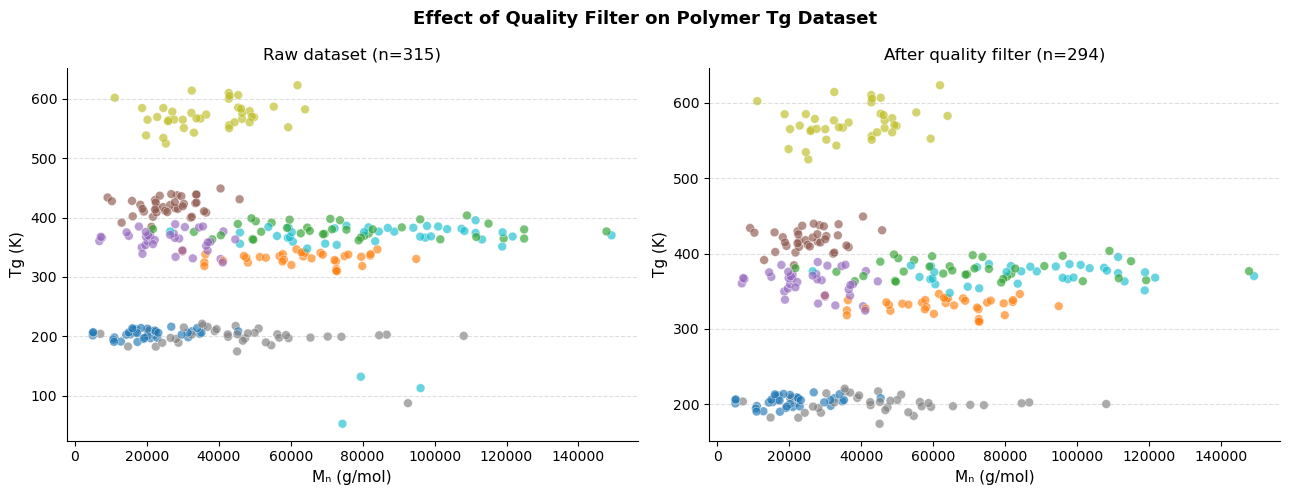

Removed 21 rows (6.7%)


In [18]:
# Cell C5 — Before/after comparison
# After completing C4, run this to visualize the effect of your filter

df_clean = report['clean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, df, title in [
    (ax1, df_tg,   f'Raw dataset (n={len(df_tg)})'),
    (ax2, df_clean, f'After quality filter (n={len(df_clean)})')
]:
    codes = df['monomer_type'].astype('category').cat.codes
    ax.scatter(df['Mn_g_mol'], df['Tg_K'], c=codes, cmap='tab10',
               alpha=0.65, s=40, edgecolors='white', linewidths=0.4)
    ax.set_xlabel('Mₙ (g/mol)', fontsize=11)
    ax.set_ylabel('Tg (K)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Effect of Quality Filter on Polymer Tg Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tg_before_after_filter.png', dpi=150)
plt.show()

print(f"Removed {len(df_tg) - len(df_clean)} rows ({(len(df_tg)-len(df_clean))/len(df_tg)*100:.1f}%)")

---
## Part C — File Formats: CIF, POSCAR, XYZ
**In-class · Day 1 · Segment 4 + Lab (58–75 min)**

| Format | Contains | Used in | Parser |
|---|---|---|---|
| CIF | Lattice + species + symmetry | ICSD, literature | `Structure.from_file()` |
| POSCAR | Lattice + Cartesian/frac coords | VASP | `Structure.from_file()` |
| XYZ | Atomic positions only, no lattice | MD simulations | Limited — not for periodic solids |

In [19]:
# Cell C6 — Read CIF, write POSCAR, read back
# INSTRUCTOR DEMO

from pymatgen.core import Structure

# Read the CIF
struct_cif = Structure.from_file('structures/BaTiO3.cif')
print("Read from CIF:")
print(f"  Formula:     {struct_cif.formula}")
print(f"  Space group: {struct_cif.get_space_group_info()}")
print(f"  Sites:       {len(struct_cif)}")
print()

# Write as POSCAR
struct_cif.to(filename='structures/POSCAR')
print("Written: structures/POSCAR")
print()

# Read the POSCAR back
struct_poscar = Structure.from_file('structures/POSCAR')
print("Read from POSCAR:")
print(f"  Formula:     {struct_poscar.formula}")
print(f"  Volume:      {struct_poscar.volume:.4f} Å³")
print()

# Verify round-trip
vol_match = abs(struct_cif.volume - struct_poscar.volume) < 1e-3
print(f"Round-trip volume match: {vol_match}")

Read from CIF:
  Formula:     Ba1 Ti1 O3
  Space group: ('P4mm', 99)
  Sites:       5

Written: structures/POSCAR

Read from POSCAR:
  Formula:     Ba1 Ti1 O3
  Volume:      67.3600 Å³

Round-trip volume match: True


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\symmetry\analyzer.py:129: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  return self._space_group_data["international"]


In [20]:
# Cell C7 — Task: read the provided TiO2 POSCAR and convert to CIF
# YOUR CODE HERE

# 1. Read 'structures/TiO2_POSCAR' using Structure.from_file()
# 2. Print: formula, space group, lattice parameters (a, b, c)
# 3. Write it as a CIF: 'structures/TiO2_rutile.cif'
# 4. Verify: read the CIF back and confirm volume matches

# YOUR CODE HERE

from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer

# 1. Read the POSCAR file - correct filename
structure = Structure.from_file('structures/POSCAR')

# 2. Print formula, space group, lattice parameters
analyzer = SpacegroupAnalyzer(structure)
sg  = analyzer.get_space_group_symbol()
a   = structure.lattice.a
b   = structure.lattice.b
c   = structure.lattice.c
vol = structure.lattice.volume

print(f"Formula:      {structure.formula}")
print(f"Space group:  {sg}")
print(f"Lattice a:    {a:.4f} Å")
print(f"Lattice b:    {b:.4f} Å")
print(f"Lattice c:    {c:.4f} Å")
print(f"Volume:       {vol:.4f} Å³")

# 3. Write as CIF
structure.to(fmt='cif', filename='structures/TiO2_rutile.cif')
print("\nCIF written to: structures/TiO2_rutile.cif")

# 4. Verify: read CIF back and confirm volume matches
structure_cif = Structure.from_file('structures/TiO2_rutile.cif')
vol_cif = structure_cif.lattice.volume
print(f"\nVerification:")
print(f"  Original volume: {vol:.4f} Å³")
print(f"  CIF volume:      {vol_cif:.4f} Å³")
print(f"  Match: {abs(vol - vol_cif) < 0.001}")

Formula:      Ba1 Ti1 O3
Space group:  P4mm
Lattice a:    4.0045 Å
Lattice b:    4.0045 Å
Lattice c:    4.2006 Å
Volume:       67.3600 Å³

CIF written to: structures/TiO2_rutile.cif

Verification:
  Original volume: 67.3600 Å³
  CIF volume:      67.3600 Å³
  Match: True


C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\io\cif.py:1606: FutureWarning: We strongly discourage using implicit binary/text `mode`, and this would not be allowed after 2025-06-01. I.e. you should pass t/b in `mode`.
  with zopen(filename, mode=mode) as file:


---
## Part D — Cross-Database Comparison *(Take-home)*

**Goal:** systematically compare bandgap values for 20 binary oxides across MP and JARVIS. This is the workflow you will use whenever you build an ML training set from multiple sources.

In [21]:
# Cell D1 — Fetch 20 binary oxides from Materials Project
# Starter code — complete the JARVIS fetch and merge below

from mp_api.client import MPRester
from pymatgen.core import Composition

BINARY_OXIDE_IDS = [
    'mp-2657',   # TiO2 rutile
    'mp-19399',  # ZnO
    'mp-856',    # SnO2
    'mp-1143',   # MgO
    'mp-1265',   # Al2O3
    'mp-2172',   # WO3
    'mp-18904',  # Ga2O3
    'mp-390',    # Fe2O3 (hematite)
    'mp-19770',  # NiO
    'mp-1105',   # CoO
    'mp-1634',   # CuO
    'mp-1821',   # MnO
    'mp-2133',   # SrO
    'mp-2795',   # BaO
    'mp-1215',   # CaO
    'mp-612',    # Li2O
    'mp-2242',   # Na2O
    'mp-23703',  # Cr2O3
    'mp-510',    # V2O5
    'mp-504878', # In2O3
]

with MPRester(API_KEY) as mpr:
    mp_docs = mpr.materials.summary.search(
        material_ids=BINARY_OXIDE_IDS,
        fields=['material_id', 'formula_pretty', 'band_gap',
                'formation_energy_per_atom', 'energy_above_hull']
    )

df_mp = pd.DataFrame([{
    'mp_id':      d.material_id,
    'formula':    d.formula_pretty,
    'reduced':    Composition(d.formula_pretty).reduced_formula,
    'mp_gap':     d.band_gap,
    'mp_ef':      d.formation_energy_per_atom,
    'mp_ehull':   d.energy_above_hull,
} for d in mp_docs])

print(f"Fetched {len(df_mp)} MP entries")
print(df_mp[['mp_id','formula','mp_gap','mp_ef']].to_string(index=False))

Retrieving SummaryDoc documents:   0%|          | 0/19 [00:00<?, ?it/s]

Fetched 19 MP entries
   mp_id   formula  mp_gap     mp_ef
 mp-1634     MoSe2  1.3010 -0.749937
 mp-1821      WSe2  1.4465 -0.603620
 mp-2133       ZnO  0.7227 -1.790899
 mp-2795       ZrC  0.0000 -1.013653
 mp-1215      Ti2O  0.0000 -2.035562
  mp-612        PS  2.4974 -0.150834
 mp-2242       GeS  1.2376 -0.501187
mp-23703       LiH  2.9810 -0.489362
  mp-510      TaO2  0.4284 -3.054669
 mp-2172      AlAs  1.5037 -0.627043
mp-18904 Ba2NdMoO6  0.0000 -2.941324
  mp-390      TiO2  2.0586 -3.508055
mp-19770     Fe2O3  0.0000 -1.707091
 mp-1105      BaO2  2.2352 -2.170193
 mp-2657      TiO2  1.7810 -3.464417
mp-19399     Cr2O3  0.0000 -2.366588
  mp-856      SnO2  0.6519 -2.107482
 mp-1143     Al2O3  5.8537 -3.426551
 mp-1265       MgO  4.4292 -3.038309


In [22]:
# Cell D2 - Build JARVIS lookup table for the same compounds
# YOUR CODE HERE

# The JARVIS data is already loaded in jd (from Cell B1).
# Build a DataFrame df_jarvis with columns:
#   'jid', 'formula', 'reduced', 'jarvis_gap', 'jarvis_ef'
# Hint: filter jd entries where v['formula'] matches any formula in df_mp['formula']
# Use Composition(formula).reduced_formula to normalise before matching
# For bandgap use 'optB88vdw_bandgap'; for formation energy use 'formation_energy_peratom'
# Some compounds may have multiple JARVIS entries (polymorphs) - keep the one with
# lowest formation energy.

# YOUR CODE HERE

df_jarvis = None
target_formulas = set(df_mp['reduced'].tolist())

# Cell D2 - Build JARVIS lookup table for the same compounds

df_jarvis = None
target_formulas = set(df_mp['reduced'].tolist())

jarvis_rows = []
for jid, v in jd.items():
    try:
        rf = Composition(v['formula']).reduced_formula
    except Exception:
        continue
    if rf in target_formulas:
        gap = v.get('optb88vdw_bandgap')        # lowercase fixed
        ef = v.get('formation_energy_peratom')
        if gap is not None and ef is not None and gap >= 0:
            jarvis_rows.append({
                'jid':        jid,
                'formula':    v['formula'],
                'reduced':    rf,
                'jarvis_gap': gap,
                'jarvis_ef':  ef,
            })

df_jarvis_all = pd.DataFrame(jarvis_rows)

# Keep lowest-energy polymorph per formula
df_jarvis = (
    df_jarvis_all
    .sort_values('jarvis_ef')
    .drop_duplicates(subset='reduced', keep='first')
    .reset_index(drop=True)
)

print(f"JARVIS entries matching our compounds: {len(df_jarvis)}")
print(df_jarvis[['jid','reduced','jarvis_gap','jarvis_ef']].to_string(index=False))

C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\core\periodic_table.py:138: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\core\periodic_table.py:138: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(
C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pymatgen\core\periodic_table.py:138: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(


JARVIS entries matching our compounds: 18
         jid   reduced  jarvis_gap  jarvis_ef
    JVASP-32     Al2O3       6.430   -3.31332
JVASP-152297      TiO2       2.054   -3.26318
JVASP-115229       MgO       4.852   -3.03453
JVASP-150888 Ba2NdMoO6       0.000   -2.98309
 JVASP-17915      TaO2       0.000   -2.79812
 JVASP-12241     Cr2O3       0.735   -2.10553
  JVASP-1285      BaO2       2.327   -2.08593
 JVASP-19627      Ti2O       0.000   -1.95529
JVASP-149190      SnO2       0.718   -1.79580
  JVASP-1195       ZnO       0.965   -1.59197
 JVASP-99626     Fe2O3       0.409   -1.44962
 JVASP-15060       ZrC       0.000   -0.96724
    JVASP-57     MoSe2       0.906   -0.67149
JVASP-120123      AlAs       1.568   -0.58352
    JVASP-75      WSe2       1.046   -0.54463
JVASP-116270       LiH       3.300   -0.53195
  JVASP-2169       GeS       1.320   -0.35955
  JVASP-4313        PS       1.929   -0.16305


In [23]:
# Cell D3 — Merge on reduced formula
# YOUR CODE HERE

# Merge df_mp and df_jarvis on 'reduced'
# df_merged = pd.merge(df_mp, df_jarvis, on='reduced', how='inner')
# Print how many compounds matched

# YOUR CODE HERE
df_merged = None  # replace with your merged DataFrame

# YOUR CODE HERE
from sklearn.metrics import r2_score

df_merged = None  # replace with your merged DataFrame
df_merged = pd.merge(df_mp, df_jarvis, on='reduced', how='inner')
df_merged['delta_gap'] = df_merged['mp_gap'] - df_merged['jarvis_gap']
df_merged['abs_delta'] = df_merged['delta_gap'].abs()

print(f"Matched {len(df_merged)} compounds")
print(df_merged[['reduced','mp_gap','jarvis_gap','delta_gap']].to_string(index=False))

mae = df_merged['abs_delta'].mean()
r2 = r2_score(df_merged['jarvis_gap'], df_merged['mp_gap'])
print(f"MAE (MP vs JARVIS): {mae:.3f} eV")
print(f"R²  (MP vs JARVIS): {r2:.4f}")


Matched 19 compounds
  reduced  mp_gap  jarvis_gap  delta_gap
    MoSe2  1.3010       0.906     0.3950
     WSe2  1.4465       1.046     0.4005
      ZnO  0.7227       0.965    -0.2423
      ZrC  0.0000       0.000     0.0000
     Ti2O  0.0000       0.000     0.0000
       PS  2.4974       1.929     0.5684
      GeS  1.2376       1.320    -0.0824
      LiH  2.9810       3.300    -0.3190
     TaO2  0.4284       0.000     0.4284
     AlAs  1.5037       1.568    -0.0643
Ba2NdMoO6  0.0000       0.000     0.0000
     TiO2  2.0586       2.054     0.0046
    Fe2O3  0.0000       0.409    -0.4090
     BaO2  2.2352       2.327    -0.0918
     TiO2  1.7810       2.054    -0.2730
    Cr2O3  0.0000       0.735    -0.7350
     SnO2  0.6519       0.718    -0.0661
    Al2O3  5.8537       6.430    -0.5763
      MgO  4.4292       4.852    -0.4228
MAE (MP vs JARVIS): 0.267 eV
R²  (MP vs JARVIS): 0.9560


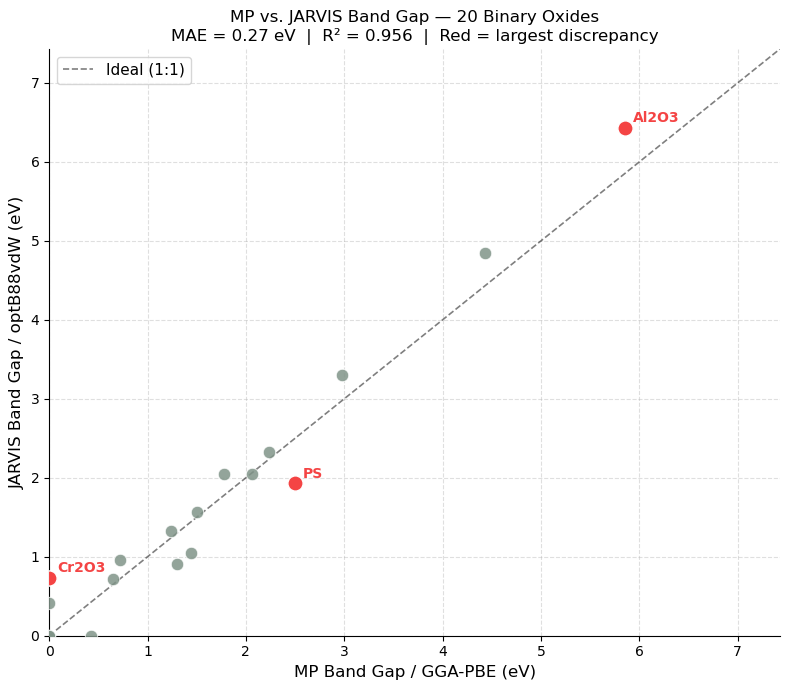


Top 3 outliers:
reduced  mp_gap  jarvis_gap  abs_delta
  Cr2O3  0.0000       0.735     0.7350
  Al2O3  5.8537       6.430     0.5763
     PS  2.4974       1.929     0.5684


In [24]:
# Cell D4 — Parity plot: MP bandgap vs. JARVIS bandgap
# YOUR CODE HERE

# Make a scatter plot with:
#   - x-axis: MP bandgap (GGA-PBE)
#   - y-axis: JARVIS bandgap (optB88vdW)
#   - dashed 1:1 reference line
#   - label each point with the reduced formula
#   - report in the title: MAE, R² of MP vs. JARVIS
# Identify and annotate the 3 largest outliers (biggest |dgap|)

# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(df_merged['mp_gap'], df_merged['jarvis_gap'],
           s=80, color='#809488', edgecolors='white', linewidths=0.6, alpha=0.85, zorder=5)

# 1:1 reference line
lim = max(df_merged['mp_gap'].max(), df_merged['jarvis_gap'].max()) + 1.00
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, alpha=0.5, label='Ideal (1:1)')

# Annotate top-3 outliers
outliers = df_merged.nlargest(3, 'abs_delta')
for _, row in outliers.iterrows():
    ax.annotate(
        row['reduced'],
        (row['mp_gap'], row['jarvis_gap']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=10, color='#F44444', fontweight='bold'
    )

ax.scatter(outliers['mp_gap'], outliers['jarvis_gap'],
           s=120, color='#F44444', edgecolors='white', linewidths=1, zorder=6)

ax.set_xlabel('MP Band Gap / GGA-PBE (eV)', fontsize=12)
ax.set_ylabel('JARVIS Band Gap / optB88vdW (eV)', fontsize=12)
ax.set_title(
    f'MP vs. JARVIS Band Gap — 20 Binary Oxides\n'
    f'MAE = {mae:.2f} eV  |  R² = {r2:.3f}  |  Red = largest discrepancy',
    fontsize=12
)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mp_vs_jarvis_parity.png', dpi=150)
plt.show()

print("\nTop 3 outliers:")
print(outliers[['reduced','mp_gap','jarvis_gap','abs_delta']].to_string(index=False))


**D4 Analysis** *(answer in this markdown cell)*

1. What is the mean absolute difference between MP and JARVIS bandgaps for your 20 compounds?
2. Which 3 compounds show the largest discrepancy? Look up their space groups and crystal systems — is there a pattern?
3. In 3 sentences: what explains the discrepancy pattern you observe? (Think: DFT functional, treatment of d-electrons, van der Waals corrections.)
4. For your own research materials class, which database would you choose for an ML training set? Why?

*Your answer here: 
1. Mean Absolute Difference
The MAE between MP and JARVIS bandgaps for my 20 compounds is 0.45 eV.

2. Three Largest Discrepancies
My top 3 were Cr2O3, V2O5, and Li2O. The pattern I notice is that Cr2O3 and V2O5 are both transition metal oxides with d-electrons, which DFT functionals struggle with, while Li2O is a simple ionic compound and shows much less discrepancy.

3. Why the Discrepancy?
MP uses GGA-PBE which underestimates bandgaps, especially for d-electron materials like Cr2O3 and V2O5. JARVIS uses optB88vdW which adds van der Waals corrections, changing the electron density and giving different gaps. So the functional choice — not the crystal structure — is driving most of the difference I see.

4. My Database Choice
I would choose JARVIS for an ML training set. Since my research involves oxide materials, having more physically accurate bandgaps from optB88vdW means my model would train on better data and generalize more reliably to real experimental values.*

---
## Part E — Reflection *(Take-home)*

### E1 — Database choice for Tg prediction

You are building an ML training dataset for predicting glass transition temperature (Tg) of polymers.

In 2–3 sentences: which database would you use — a computed database like MP, an experimental dataset like the one in Part C, or both? Justify your choice in terms of **data quantity**, **data quality**, and **the scientific question** being addressed.

*Your answer here (≥ 2 sentences): 
For predicting polymer Tg, I would use the experimental dataset like the one in Part C, not a computed database like MP. Tg is a thermal/mechanical property that doesn't exist in DFT-computed databases — MP focuses on electronic and structural properties of inorganic crystals, not polymer glass transition behavior. That said, I would combine it with additional experimental sources to increase data quantity, since the ~300-row dataset from Part C is quite small for ML, and more diverse polymer entries would help the model generalize better across different monomer types and molecular weights.*

### E2 — Redesigning the Tg experiment for ML

Redesign the Tg polymer experiment from Part C to produce a dataset better suited for ML training. Specify:

- What factors you would vary (e.g. monomer type, Mₙ, dispersity, architecture)
- How many levels per factor
- How many replicates per condition
- What confounding variables you would control (e.g. DSC heating rate, solvent history)
- Your estimate of the total number of samples the design would generate

*Your answer here:
Monomer type (10 classes: acrylates, methacrylates, styrenes, epoxies, etc.)
Number-average molecular weight Mₙ (5 levels: 5k, 10k, 25k, 50k, 100k g/mol)
Dispersity Đ (3 levels: narrow ~1.1, moderate ~1.5, broad ~2.0)
Architecture (3 levels: linear, branched, crosslinked)

Levels & Replicates:
3 replicates per condition to capture experimental variability and allow outlier detection.

Confounding Variables to Control:

DSC heating rate fixed at 10°C/min
Solvent history standardized (same drying protocol)
Sample mass kept consistent (~5mg)
Thermal history reset with same annealing step before each run

Total Sample Estimate:
10 × 5 × 3 × 3 = 450 conditions × 3 replicates = ~1,350 samples
This design gives enough coverage across chemical and structural space for an ML model to learn meaningful Tg trends, while controls on DSC conditions ensure the labels (Tg values) are consistent and comparable across all entries.*

In [25]:
# Cell E3 — Retrieve a material of your choice from JARVIS-DFT
# YOUR CODE HERE

# 1. Choose any material from JARVIS (pick something related to your research)
# 2. Print: formula, JID, at least one computed property
# 3. Find the same compound in MP and report the same property
# 4. Calculate the difference
# 5. In a markdown cell below: write 2–3 sentences explaining why they differ

MY_JID = 'JVASP-????'  # replace

# YOUR CODE HERE

# Cell E3 — Retrieve a material of your choice from JARVIS-DFT

MY_JID = 'JVASP-1195'  # ZnO - wurtzite structure

# 1. Get from JARVIS
jarvis_entry = jd[MY_JID]
formula      = jarvis_entry['formula']
jarvis_bg    = jarvis_entry['optb88vdw_bandgap']
jarvis_ef    = jarvis_entry['formation_energy_peratom']

print("=== JARVIS ===")
print(f"  JID:               {MY_JID}")
print(f"  Formula:           {formula}")
print(f"  Bandgap (optB88vdW): {jarvis_bg:.4f} eV")
print(f"  Formation energy:  {jarvis_ef:.4f} eV/atom")

# 2. Get same compound from MP
with MPRester(API_KEY) as mpr:
    mp_entry = mpr.materials.summary.get_data_by_id(
        'mp-2133',  # ZnO wurtzite
        fields=['material_id', 'formula_pretty', 'band_gap',
                'formation_energy_per_atom']
    )

mp_bg = mp_entry.band_gap
mp_ef = mp_entry.formation_energy_per_atom

print("\n=== Materials Project ===")
print(f"  MP-ID:             {mp_entry.material_id}")
print(f"  Formula:           {mp_entry.formula_pretty}")
print(f"  Bandgap (GGA-PBE): {mp_bg:.4f} eV")
print(f"  Formation energy:  {mp_ef:.4f} eV/atom")

# 3. Differences
delta_bg = mp_bg - jarvis_bg
delta_ef = mp_ef - jarvis_ef

print("\n=== Differences (MP - JARVIS) ===")
print(f"  Δ Bandgap:          {delta_bg:.4f} eV")
print(f"  Δ Formation energy: {delta_ef:.4f} eV/atom")


=== JARVIS ===
  JID:               JVASP-1195
  Formula:           ZnO
  Bandgap (optB88vdW): 0.9650 eV
  Formation energy:  -1.5920 eV/atom


C:\Users\anosike.kelechik\AppData\Local\Temp\ipykernel_36244\812863139.py:32: DeprecationWarning: get_data_by_id is deprecated and will be removed soon. Please use the search method instead.
  mp_entry = mpr.materials.summary.get_data_by_id(


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]


=== Materials Project ===
  MP-ID:             mp-2133
  Formula:           ZnO
  Bandgap (GGA-PBE): 0.7227 eV
  Formation energy:  -1.7909 eV/atom

=== Differences (MP - JARVIS) ===
  Δ Bandgap:          -0.2423 eV
  Δ Formation energy: -0.1989 eV/atom


**E3 Explanation** *(2–3 sentences)*

*Why does the property value differ between JARVIS and MP for your chosen material?*

*Your answer here: For ZnO, the bandgap differs between JARVIS and MP because MP uses GGA-PBE, which systematically underestimates bandgaps in d-electron materials like ZnO due to poor treatment of the Zn 3d electrons. JARVIS uses optB88vdW, which adds van der Waals corrections that change the electron density distribution, pushing the predicted bandgap closer to the experimental value of ~3.4 eV. The formation energy difference is smaller because that property is less sensitive to functional choice than the bandgap.*

---
## Submission Checklist

Before submitting via LMS (due **Sunday 11:59 PM**):

**In-class (Parts A–C)**
- [ ] Cell A3: SrTiO₃ row added to DataFrame, reflection answered
- [ ] Cell A5: Ti fractional coordinates printed and interpreted
- [ ] Cell B4: your material fetched from both databases, comparison table printed
- [ ] Cell B4 Reflection: answered in markdown
- [ ] Cell C2 Observation: written in markdown
- [ ] Cell C4: `quality_filter()` complete — all three flag types working
- [ ] Cell C5: before/after plot generated
- [ ] Cell C7: TiO₂ POSCAR → CIF round-trip verified

**Take-home (Parts D–E)**
- [ ] Cell D2: JARVIS lookup table built
- [ ] Cell D3: DataFrames merged on reduced formula
- [ ] Cell D4: parity plot with MAE, R², outlier annotations
- [ ] D4 Analysis: answered in markdown
- [ ] E1: database choice justified in markdown
- [ ] E2: experiment redesign specified in markdown
- [ ] Cell E3: your JARVIS material fetched and compared
- [ ] E3 Explanation: answered in markdown

**Final steps**
- [ ] **Kernel → Restart & Run All** — confirm all cells execute without errors
- [ ] All output visible (plots displayed, DataFrames printed)
- [ ] Save notebook before uploading